# Proyecto Integrador - Analisis de datos con SQL y Python


## Resumen del estudio

El presente documento constituye el reporte técnico de un estudio de análisis de datos aplicado sobre la base de datos relacional `world`, un dataset de referencia geográfica y demográfica ampliamente utilizado en la literatura de enseñanza de SQL. El estudio tiene como objetivo evaluar patrones demográficos, lingüísticos y socioeconómicos a nivel país, ciudad y continente, mediante la integración de dos componentes tecnológicos: un sistema gestor de bases de datos relacional (**MySQL**) y un entorno de análisis y visualización de datos (**Python**).

## Descripción del conjunto de datos

La base de datos `world` está compuesta por tres tablas relacionadas mediante claves foráneas, con la siguiente estructura:

**Tabla `country`** — 239 registros, 15 atributos: `Code` (clave primaria, código ISO de 3 letras), `Name`, `Continent`, `Region`, `SurfaceArea` (superficie en km²), `IndepYear` (año de independencia), `Population`, `LifeExpectancy` (esperanza de vida en años), `GNP` y `GNPOld` (Producto Nacional Bruto actual e histórico, en millones de USD), `LocalName`, `GovernmentForm`, `HeadOfState`, `Capital` (clave foránea hacia `city`) y `Code2` (código ISO de 2 letras). Se identificaron valores nulos en `IndepYear` (47 registros), `GNPOld` (61), `LifeExpectancy` (17), `HeadOfState` (1) y `Capital` (7), atribuibles principalmente a territorios sin gobierno soberano o dependencias administrativas.

**Tabla `city`** — 4,079 registros, 5 atributos: `Id` (clave primaria), `Name`, `CountryCode` (clave foránea hacia `country.Code`), `District` y `Population`.

**Tabla `countrylanguage`** — 984 registros, 4 atributos: `CountryCode` (clave foránea hacia `country.Code`), `Language`, `IsOfficial` (booleano representado como `T`/`F`) y `Percentage` (porcentaje de la población que habla dicho idioma).

Esta estructura relacional —una tabla central (`country`) vinculada a dos tablas dependientes (`city`, `countrylanguage`) mediante `CountryCode`— constituye la base sobre la cual se ejecutaron operaciones de unión (`JOIN`) a lo largo del estudio.

## Preparación del entorno

### Instalación e importación de librerías

El entorno de trabajo requirió la instalación de las siguientes dependencias mediante el gestor de paquetes `pip`:

```bash
python -m pip install mysql-connector-python pandas seaborn matplotlib numpy python-dotenv
```

Cada librería cumple una función específica dentro del pipeline analítico:

- **`mysql-connector-python`**: driver oficial de MySQL para Python, responsable de establecer la conexión TCP/IP con el servidor y ejecutar sentencias SQL desde el entorno de programación.
- **`pandas`**: manipulación y estructuración de los resultados de las consultas en objetos `DataFrame`, permitiendo operaciones vectorizadas de agregación, ordenamiento y formateo.
- **`seaborn`**: capa de visualización estadística construida sobre `matplotlib`, utilizada para gráficos categóricos (barras) con estética y paletas de color estandarizadas.
- **`matplotlib`**: motor de graficación base, empleado directamente para histogramas, gráficos de dispersión y de sectores (pastel), así como para el control fino de ejes y formateo numérico.
- **`numpy`**: cálculo numérico, utilizado específicamente para el ajuste de regresión lineal (`polyfit`) en el análisis de correlación.
- **`python-dotenv`**: gestión de variables de entorno para la carga segura de credenciales de conexión.

### Gestión segura de credenciales

Con el propósito de evitar la exposición de credenciales sensibles dentro del código fuente —una vulnerabilidad común cuando el notebook es compartido o versionado—, las credenciales del servidor MySQL (host, usuario, contraseña y base de datos) se externalizaron a un archivo `.env`, cargado en tiempo de ejecución mediante la función `load_dotenv()` de la librería `python-dotenv`. Este método lee el archivo `.env` ubicado en el directorio del proyecto y expone sus pares clave-valor como variables de entorno del sistema operativo, accesibles posteriormente mediante `os.getenv()`. El archivo `.env` fue además incluido en `.gitignore`, excluyéndolo de cualquier sistema de control de versiones y garantizando que la credencial nunca se distribuya junto con el código.

### Técnica de conexión

La conexión entre el entorno Python y el servidor MySQL (administrado localmente mediante MySQL Workbench) se estableció a través del método `mysql.connector.connect()`, el cual instancia un objeto de conexión persistente sobre el cual se ejecutan las consultas mediante `pandas.read_sql()` (para operaciones de lectura) y `cursor.execute()` + `conn.commit()` (para operaciones de escritura, como el `UPDATE` del ejercicio 5).

## Metodología por fase

**Fase 1 — Revisión inicial de los datos.** Previo a la resolución de los ejercicios, se realizó una auditoría exploratoria de las tres tablas mediante `.info()` (tipos de dato y conteo de valores no nulos), `.describe()` (estadísticos de tendencia central y dispersión de las variables numéricas) y verificación de registros duplicados mediante `.duplicated()`. Esta fase permitió identificar la magnitud y distribución de los valores faltantes antes de definir la estrategia de tratamiento de nulos.

**Fase 2 — Resolución de consultas.** Se emplearon las siguientes técnicas SQL de forma recurrente a lo largo del estudio:

- **Consultas de selección y filtrado** (`SELECT` con `WHERE`) para extraer subconjuntos de países o ciudades según criterios geográficos o demográficos.
- **Uniones internas** (`INNER JOIN`) entre `country` y `city` (mediante `CountryCode = Code`) y entre `country` y `countrylanguage` (mediante `Code = CountryCode`), necesarias para responder preguntas que requerían atributos de más de una tabla (por ejemplo, ciudades filtradas por continente del país al que pertenecen).
- **Funciones de agregación** (`SUM`, `COUNT`, `COUNT DISTINCT`) combinadas con `GROUP BY`, utilizadas para calcular totales de población por continente y conteo de idiomas únicos por continente.
- **Ordenamiento y limitación de resultados** (`ORDER BY`, `LIMIT`) para obtener rankings (top 5 países por superficie, ciudades ordenadas por población).
- **Operaciones de escritura** (`UPDATE`), empleadas puntualmente para modificar el valor de población de un registro específico, con verificación posterior mediante una consulta de lectura.
- **Cálculos derivados en la propia consulta SQL** (por ejemplo, densidad poblacional como `Population / SurfaceArea`, o PIB per cápita como `GNP * 1,000,000 / Population`), evitando cálculos adicionales en Python y manteniendo la lógica de transformación centralizada en la capa de base de datos.

**Fase 3 — Visualización.** Se aplicaron distintas técnicas gráficas según la naturaleza de la variable analizada: gráficos de barras (`seaborn.barplot`) para comparaciones categóricas entre países, ciudades, continentes e idiomas; histogramas (`matplotlib.pyplot.hist`) para observar la distribución de una variable continua (esperanza de vida); gráficos de dispersión (`matplotlib.pyplot.scatter`) para explorar relaciones bivariadas coloreadas por categoría (continente); y gráficos de sectores (`matplotlib.pyplot.pie`) para representar proporciones de composición.

Adicionalmente, se incorporaron métodos de visualización orientados a mejorar la legibilidad de valores numéricos de gran magnitud —frecuentes en variables como población o superficie—, mediante la aplicación de separadores de miles. Para las tablas de resultados (`DataFrame`), este formateo se implementó mediante el método `pandas.Styler.format()`, que aplica una máscara de presentación (`{:,.0f}` para enteros, `{:,.2f}` para valores con decimales) sin alterar el tipo de dato subyacente, preservando así la capacidad de realizar cálculos posteriores sobre los mismos datos. Para los ejes de los gráficos, se empleó `matplotlib.ticker.FuncFormatter`, que permite definir una función de formateo personalizada aplicada a cada marca del eje, evitando la notación científica por defecto de `matplotlib` (por ejemplo, `1.5e8`) y sustituyéndola por una representación numérica completa y separada por comas (`150,000,000`). Esta decisión metodológica responde a criterios de comunicación efectiva de resultados, particularmente relevante en un estudio orientado a un público no necesariamente técnico.

**Fase 4 — Análisis de correlación (ejercicio complementario).** Se evaluó la asociación entre el Producto Nacional Bruto (GNP) y la esperanza de vida mediante dos coeficientes complementarios: el coeficiente de correlación de **Pearson**, que mide asociación lineal, y el coeficiente de **Spearman**, que mide asociación monótona basada en rangos. La comparación entre ambos coeficientes —calculados tanto para el GNP total como para el GNP per cápita— permitió inferir la naturaleza no lineal de la relación entre riqueza económica y esperanza de vida.

- **Nota terminológica:** la columna original de la base de datos `world` se denomina `GNP` (*Gross National Product*, Producto Nacional Bruto), la cual difiere técnicamente del PIB (Producto Interno Bruto) en que incluye ingresos generados por residentes en el extranjero. A lo largo de este estudio se utiliza el término "PIB" como equivalente simplificado, en línea con el alias asignado a la columna en las consultas SQL (`GNP AS ProductoInternoBruto`).

## Factorización del componente de visualización

Durante la Fase 3 se identificó que la lógica de graficación por dispersión coloreada por continente se repetía de forma equivalente en tres ejercicios distintos (densidad poblacional, GNP total vs esperanza de vida, y GNP per cápita vs esperanza de vida), diferenciándose únicamente en las columnas involucradas y los textos descriptivos del gráfico. Esta duplicación de código representaba dos riesgos metodológicos: (i) inconsistencia visual entre gráficos que debían ser comparables entre sí, ante la posibilidad de que una modificación de estilo se aplicara en una instancia y se omitiera en otra; y (ii) reducción de la mantenibilidad y legibilidad del documento, al diluir la lógica relevante de cada ejercicio entre bloques de código repetidos.

En consecuencia, se abstrajo dicha lógica en una función reutilizable, `scatter_por_continente()`, parametrizada por el DataFrame de origen, las columnas a graficar, los textos del gráfico y la necesidad de aplicar escala logarítmica en los ejes. Esta refactorización responde al principio de ingeniería de software **DRY (Don't Repeat Yourself)**, y permitió reducir cada instancia de gráfico de dispersión a una única invocación de función, preservando el comportamiento original mientras se mejora la trazabilidad y consistencia del análisis.


# Índice Interactivo

- [Conexión a MySQL](#Importar-conector-para-enlazar-con-my-SQL)
- [Exploración inicial](#Primeras-consultas-de-analisis-Exploratorio)
- [Metodología](#Metodología-y-técnicas-utilizadas)
- **Consultas**
  1. [Población por país — Europa](#1.-Nombre-y-poblacion-de-paises-del-continente-europeo)
  2. [5 países más grandes](#2.-Nombre-y-areas-de-superficie-de-los-5-paises-mas-grandes-del-mundo-(DESC))
  3. [Población por continente](#3.-Poblacion-total-de-todos-los-paises-de-cada-continente)
  4. [Ciudades de Europa](#4.-Ciudades-y-poblacion-de-todos-los-paises-de-Europa,-ordenados-por-la-poblacion-de-la-ciudad-de-manera-descendente)
  5. [Actualizar población de China](#5.-Actualizar-la-poblacion-de-China-(CHN)-a-1.500.000.000)
  6. [Idiomas oficiales en Sudamérica](#6.-Idiomas-oficiales-en-sudamerica-y-grafica-cuantos-paises-comparten-el-idioma-oficial)
  7. [Esperanza de vida > 75](#7.-Paises-con-esperanza-de-vida->75-años,-histograma-de-distribucion)
  8. [Densidad poblacional](#8.-Densidad-poblacional-de-todos-los-paises,-grafico-de-dispersion-entre-superficie-y-poblacion-con-color-como-la-funcion-de-continente)
  9. [Ciudades +5M habitantes](#9.-Ciudades-con-mas-de-5-millones-de-habitantes-en-grafico-de-barras-horizontal)
  10. [Idiomas por continente](#10.-Grafico-de-pastel-de-idiomas-que-se-hablan-por-continente)
  11. [PLUS: GNP vs esperanza de vida](#11.-PLUS:-Existe-correlacion-entre-el-GNP-y-la-expectativa-de-vida?)
- [Conclusiones generales](#Conclusiones-generales-del-proyecto)


## Importar conector para enlazar con my SQL

In [44]:
import mysql.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Conectar VSC con servidor de MYSQL Workbench

In [45]:
from dotenv import load_dotenv
import os

load_dotenv()

conn = mysql.connector.connect(
    host=os.getenv("MYSQL_HOST"),
    user=os.getenv("MYSQL_USER"),
    password=os.getenv("MYSQL_PASSWORD"),
    database=os.getenv("MYSQL_DATABASE")
)
print("Conexion exitosa" if conn.is_connected() else "conexion fallida")


Conexion exitosa


### Primeras consultas de analisis Exploratorio

In [46]:
query = 'SELECT * FROM country;'
df_country = pd.read_sql(query, conn)
df_country

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/1298308678.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_country = pd.read_sql(query, conn)


,Code,Name,Continent,Region,SurfaceArea,IndepYear,Population,LifeExpectancy,GNP,GNPOld,LocalName,GovernmentForm,HeadOfState,Capital,Code2
0,ABW,Aruba,North America,Caribbean,193.0,NaN,103000,78.4,828.0,793.0,Aruba,Nonmetropolitan Territory of The Netherlands,Beatrix,129.0,AW
1,AFG,Afghanistan,Asia,Southern and Central Asia,652090.0,1919.0,22720000,45.9,5976.0,NaN,Afganistan/Afqanestan,Islamic Emirate,Mohammad Omar,1.0,AF
2,AGO,Angola,Africa,Central Africa,1246700.0,1975.0,12878000,38.3,6648.0,7984.0,Angola,Republic,José Eduardo dos Santos,56.0,AO
3,AIA,Anguilla,North America,Caribbean,96.0,NaN,8000,76.1,63.2,NaN,Anguilla,Dependent Territory of the UK,Elisabeth II,62.0,AI
4,ALB,Albania,Europe,Southern Europe,28748.0,1912.0,3401200,71.6,3205.0,2500.0,Shqipëria,Republic,Rexhep Mejdani,34.0,AL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,YEM,Yemen,Asia,Middle East,527968.0,1918.0,18112000,59.8,6041.0,5729.0,Al-Yaman,Republic,Ali Abdallah Salih,1780.0,YE
235,YUG,Yugoslavia,Europe,Southern Europe,102173.0,1918.0,10640000,72.4,17000.0,NaN,Jugoslavija,Federal Republic,Vojislav Koštunica,1792.0,YU
236,ZAF,South Africa,Africa,Southern Africa,1221037.0,1910.0,40377000,51.1,116729.0,129092.0,South Africa,Republic,Thabo Mbeki,716.0,ZA
237,ZMB,Zambia,Africa,Eastern Africa,752618.0,1964.0,9169000,37.2,3377.0,3922.0,Zambia,Republic,Frederick Chiluba,3162.0,ZM


In [47]:
df_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Code            239 non-null    object 
 1   Name            239 non-null    object 
 2   Continent       239 non-null    object 
 3   Region          239 non-null    object 
 4   SurfaceArea     239 non-null    float64
 5   IndepYear       192 non-null    float64
 6   Population      239 non-null    int64  
 7   LifeExpectancy  222 non-null    float64
 8   GNP             239 non-null    float64
 9   GNPOld          178 non-null    float64
 10  LocalName       239 non-null    object 
 11  GovernmentForm  239 non-null    object 
 12  HeadOfState     238 non-null    object 
 13  Capital         232 non-null    float64
 14  Code2           239 non-null    object 
dtypes: float64(6), int64(1), object(8)
memory usage: 28.1+ KB


In [48]:
query= 'SELECT * FROM country WHERE LifeExpectancy IS NULL;'
df_country_null = pd.read_sql(query, conn)
df_country_null

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/3316651361.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_country_null = pd.read_sql(query, conn)


,Code,Name,Continent,Region,SurfaceArea,IndepYear,Population,LifeExpectancy,GNP,GNPOld,LocalName,GovernmentForm,HeadOfState,Capital,Code2
0,ATA,Antarctica,Antarctica,Antarctica,13120000.0,NaN,0,None,0.0,None,–,Co-administrated,,NaN,AQ
1,ATF,French Southern territories,Antarctica,Antarctica,7780.0,NaN,0,None,0.0,None,Terres australes françaises,Nonmetropolitan Territory of France,Jacques Chirac,NaN,TF
2,BVT,Bouvet Island,Antarctica,Antarctica,59.0,NaN,0,None,0.0,None,Bouvetøya,Dependent Territory of Norway,Harald V,NaN,BV
3,CCK,Cocos (Keeling) Islands,Oceania,Australia and New Zealand,14.0,NaN,600,None,0.0,None,Cocos (Keeling) Islands,Territory of Australia,Elisabeth II,2317.0,CC
4,CXR,Christmas Island,Oceania,Australia and New Zealand,135.0,NaN,2500,None,0.0,None,Christmas Island,Territory of Australia,Elisabeth II,1791.0,CX
5,FLK,Falkland Islands,South America,South America,12173.0,NaN,2000,None,0.0,None,Falkland Islands,Dependent Territory of the UK,Elisabeth II,763.0,FK
6,HMD,Heard Island and McDonald Islands,Antarctica,Antarctica,359.0,NaN,0,None,0.0,None,Heard and McDonald Islands,Territory of Australia,Elisabeth II,NaN,HM
7,IOT,British Indian Ocean Territory,Africa,Eastern Africa,78.0,NaN,0,None,0.0,None,British Indian Ocean Territory,Dependent Territory of the UK,Elisabeth II,NaN,IO
8,NFK,Norfolk Island,Oceania,Australia and New Zealand,36.0,NaN,2000,None,0.0,None,Norfolk Island,Territory of Australia,Elisabeth II,2806.0,NF
9,NIU,Niue,Oceania,Polynesia,260.0,NaN,2000,None,0.0,None,Niue,Nonmetropolitan Territory of New Zealand,Elisabeth II,2805.0,NU


In [49]:
query = 'SELECT * FROM city;'
df_city = pd.read_sql(query, conn)
df_city

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/3369053581.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_city = pd.read_sql(query, conn)


,ID,Name,CountryCode,District,Population
0,1,Kabul,AFG,Kabol,1780000
1,2,Qandahar,AFG,Qandahar,237500
2,3,Herat,AFG,Herat,186800
3,4,Mazar-e-Sharif,AFG,Balkh,127800
4,5,Amsterdam,NLD,Noord-Holland,731200
...,...,...,...,...,...
4074,4075,Khan Yunis,PSE,Khan Yunis,123175
4075,4076,Hebron,PSE,Hebron,119401
4076,4077,Jabaliya,PSE,North Gaza,113901
4077,4078,Nablus,PSE,Nablus,100231


In [50]:
df_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4079 entries, 0 to 4078
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           4079 non-null   int64 
 1   Name         4079 non-null   object
 2   CountryCode  4079 non-null   object
 3   District     4079 non-null   object
 4   Population   4079 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 159.5+ KB


In [51]:
query = 'SELECT * FROM countrylanguage;'
df_countrylanguage = pd.read_sql(query, conn)
df_countrylanguage


/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/2046604527.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_countrylanguage = pd.read_sql(query, conn)


,CountryCode,Language,IsOfficial,Percentage
0,ABW,Dutch,T,5.3
1,ABW,English,F,9.5
2,ABW,Papiamento,F,76.7
3,ABW,Spanish,F,7.4
4,AFG,Balochi,F,0.9
...,...,...,...,...
979,ZMB,Tonga,F,11.0
980,ZWE,English,T,2.2
981,ZWE,Ndebele,F,16.2
982,ZWE,Nyanja,F,2.2


In [52]:
df_countrylanguage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryCode  984 non-null    object 
 1   Language     984 non-null    object 
 2   IsOfficial   984 non-null    object 
 3   Percentage   984 non-null    float64
dtypes: float64(1), object(3)
memory usage: 30.9+ KB


In [53]:
df_country[['SurfaceArea', 'Population', 'LifeExpectancy', 'GNP', 'GNPOld']].describe()


,SurfaceArea,Population,LifeExpectancy,GNP,GNPOld
count,2.390000e+02,2.390000e+02,222.000000,2.390000e+02,1.780000e+02
mean,6.232481e+05,2.636482e+07,66.486036,1.228239e+05,1.655343e+05
std,1.924140e+06,1.204275e+08,11.519267,6.379976e+05,7.204689e+05
min,4.000000e-01,0.000000e+00,37.200000,0.000000e+00,1.570000e+02
25%,2.275000e+03,2.380000e+05,60.300000,6.400000e+02,2.187000e+03
50%,7.174000e+04,3.869000e+06,70.150000,4.787000e+03,8.421000e+03
75%,3.987545e+05,1.493550e+07,75.500000,2.994450e+04,7.114550e+04
max,1.707540e+07,1.500000e+09,83.500000,8.510700e+06,8.110900e+06


In [54]:
# Verificación de duplicados en cada tabla
print(f"Duplicados en country: {df_country.duplicated().sum()}")
print(f"Duplicados en city: {df_city.duplicated().sum()}")
print(f"Duplicados en countrylanguage: {df_countrylanguage.duplicated().sum()}")


Duplicados en country: 0
Duplicados en city: 0
Duplicados en countrylanguage: 0


### Comentarios seccion 1

    - La tabla country contiene datos de 238 paises, con 15 columnas que corresponden a codigo de pais(KEY), nombre de pais, continente, region, superficie, año de independencia (47 nulos), Poblacion, Expectativa de vida (17 nulos), GNP (Producto interno bruto), GNPOld(Producto interno bruto del ejercicio anual anterior)(61 nulos), Local name, Sistema de gobierno, Representatnte del estado (1 nulo), Capital (poblacion), Codigo2.
    - Los datos nulos actuales en la tabla country no representan distorsion para el analisis propuesto en el ejercicio, por lo que se mantendran para no tener perdida transversal significativa de datos.
    - No existe ninguna pregunta que relacione el GNP con la expectativa de vida, valdra la pena revisar si existe alguna correlacion.
    - La tabla city contiene 4079 datos relacionados a ciudades de los paises, sin datos nulos encontrados, en 5 variables, ID, Name, CountryCode(KEY), Distrito, poblacion, serviran para relacionar la poblacion de las ciudades de los paises
    - La tabla CountryLanguages contiene informacion de los idiomas hablados en los paises, 984 entradas con country code (KEY), Idioma, Es oficial (BOO), Porcentaje.
    - El análisis de estadísticas descriptivas confirma rangos coherentes (sin valores negativos en población/superficie) y no se detectaron registros duplicados en ninguna de las tres tablas.


### Metodología y técnicas utilizadas

- **Conexión:** `mysql-connector-python` para establecer la conexión Python → MySQL (servidor local, mismo backend que MySQL Workbench), y `pandas.read_sql()` para traer cada resultado directamente como DataFrame.
- **Consultas:** SQL estándar (`SELECT`, `JOIN`, `GROUP BY`, `ORDER BY`, `UPDATE`) ejecutado íntegramente desde Python, cumpliendo el objetivo del caso práctico de integrar SQL + Python.
- **Tratamiento de nulos:** se decidió **no eliminar ni imputar** los valores nulos de `country` (17 en `LifeExpectancy`, 47 en `IndepYear`, 61 en `GNPOld`, 1 en `HeadOfState`, 7 en `Capital`), porque:
  - Son una proporción baja del total (ej. 17/239 ≈ 7% en `LifeExpectancy`).
  - Corresponden en su mayoría a territorios pequeños, deshabitados o dependencias administrativas (Antártida, islas del Pacífico e Índico deshabitadas, Vaticano, Svalbard), donde el nulo refleja la naturaleza del territorio y no un error de captura.
  - Eliminar la fila completa habría hecho perder columnas válidas de ese mismo registro que sí se usan en otros ejercicios.
  - En su lugar, se filtraron puntualmente con `WHERE columna IS NOT NULL` únicamente en las consultas donde esa columna concreta era la variable de análisis (ejercicio 7 y el análisis de correlación GNP–esperanza de vida).
- **Visualización:** `matplotlib` para dispersión, histograma, barras horizontales y pastel; `seaborn` para barras verticales con paleta de color en la sección final de gráficos.
- **Análisis de correlación (ejercicio plus):** se calcularon los coeficientes de **Pearson** (relación lineal) y **Spearman** (relación monótona / de rangos) para poder distinguir si la asociación entre GNP y esperanza de vida era lineal o no.

# Consultas 

## 1. Nombre y poblacion de paises del continente europeo

In [55]:
querycountrieseu= 'SELECT Name AS Pais, Population AS Poblacion FROM country WHERE continent = "Europe" ORDER BY Population DESC;'
df_europe_countries = pd.read_sql(querycountrieseu, conn)
df_europe_countries.style.format({'Poblacion': '{:,.0f}'})

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/3239425512.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_europe_countries = pd.read_sql(querycountrieseu, conn)


,Pais,Poblacion
0,Russian Federation,"146,934,000"
1,Germany,"82,164,700"
2,United Kingdom,"59,623,400"
3,France,"59,225,700"
4,Italy,"57,680,000"
5,Ukraine,"50,456,000"
6,Spain,"39,441,700"
7,Poland,"38,653,600"
8,Romania,"22,455,500"
9,Netherlands,"15,864,000"


/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/2070924575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Poblacion', y='Pais', data=df_europe_countries, palette='viridis')


Text(0, 0.5, 'Países')

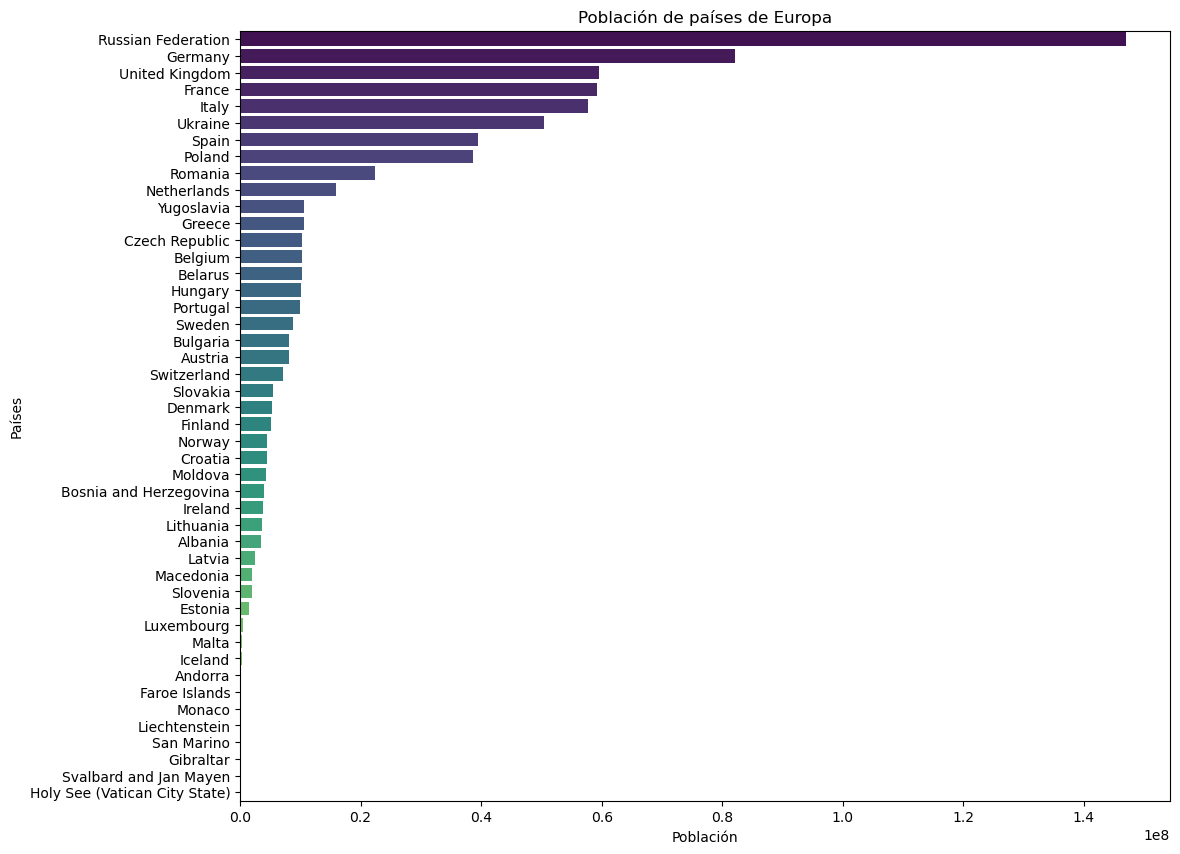

In [56]:
plt.figure(figsize=(12, 10))
sns.barplot(x='Poblacion', y='Pais', data=df_europe_countries, palette='viridis')
plt.title('Población de países de Europa')
plt.xlabel('Población')
plt.ylabel('Países')  

**Conclusión — Ejercicio 1:** la Federación Rusa lidera ampliamente la población europea (~147M), seguida de Alemania (~82M), Reino Unido (~60M), Francia (~59M) e Italia (~58M). La distribución está muy sesgada: un grupo pequeño de países grandes concentra buena parte de la población del continente, mientras la mayoría de los ~40 países europeos de la lista está por debajo de los 10 millones de habitantes.

## 2. Nombre y areas de superficie de los 5 paises mas grandes del mundo (DESC)

In [57]:
query= 'SELECT Name AS Pais, SurfaceArea AS Superficie FROM country ORDER BY SurfaceArea DESC LIMIT 5;'
df_surface_area = pd.read_sql(query, conn)
df_surface_area.style.format({'Superficie': '{:,.2f}'})

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/3753620183.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_surface_area = pd.read_sql(query, conn)


,Pais,Superficie
0,Russian Federation,"17,075,400.00"
1,Antarctica,"13,120,000.00"
2,Canada,"9,970,610.00"
3,China,"9,572,900.00"
4,United States,"9,363,520.00"


/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/1346562459.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Superficie', y='Pais', data=df_surface_area, palette='magma')


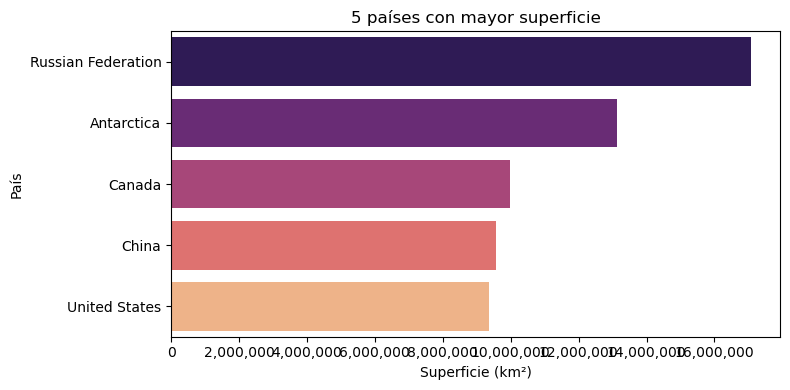

In [58]:
import matplotlib.ticker as ticker

plt.figure(figsize=(8, 4))
sns.barplot(x='Superficie', y='Pais', data=df_surface_area, palette='magma')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title('5 países con mayor superficie')
plt.xlabel('Superficie (km²)')
plt.ylabel('País')
plt.tight_layout()
plt.show()

**Conclusión — Ejercicio 2:** los 5 países más extensos son Rusia (17.08M km²), Antártida (13.12M km², sin población permanente), Canadá (9.97M km²), China (9.57M km²) y Estados Unidos (9.36M km²). Es un buen punto de partida para el ejercicio 8: superficie grande no implica automáticamente alta población — de hecho Rusia y Canadá, pese a estar entre los más extensos, tienen densidades poblacionales bajas, mientras países mucho más pequeños en superficie concentran densidades altísimas.

## 3. Poblacion total de todos los paises de cada continente

In [59]:
query = 'SELECT Continent AS Continente, SUM(Population) AS Poblacion FROM country GROUP BY Continent;'
df_population_continent = pd.read_sql(query, conn) 
df_population_continent.style.format({'Poblacion': '{:,.0f}'})

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/171154299.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_population_continent = pd.read_sql(query, conn)


,Continente,Poblacion
0,North America,"482,993,000"
1,Asia,"3,927,467,700"
2,Africa,"784,475,000"
3,Europe,"730,074,600"
4,South America,"345,780,000"
5,Oceania,"30,401,150"
6,Antarctica,0


/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/3816245471.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Poblacion', y='Continente', data=df_population_continent_sorted, palette='crest')


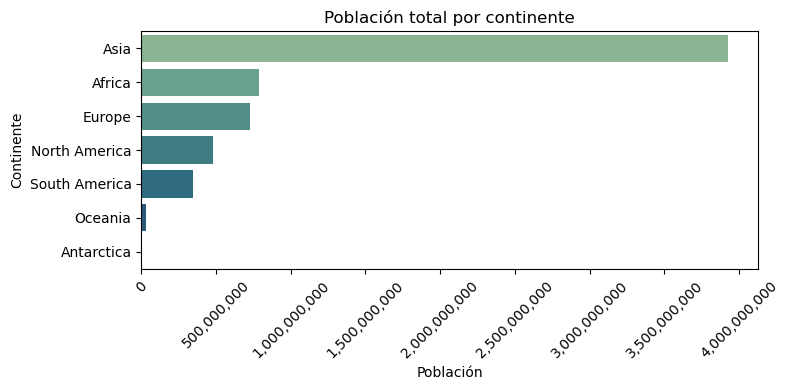

In [60]:
df_population_continent_sorted = df_population_continent.sort_values('Poblacion', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Poblacion', y='Continente', data=df_population_continent_sorted, palette='crest')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.title('Población total por continente')
plt.xlabel('Población')
plt.ylabel('Continente')
plt.tight_layout()
plt.show()


**Conclusión — Ejercicio 3:** Asia concentra la mayor población total (~3,705M), casi 5 veces la de África (~784M), que ocupa el segundo lugar. Europa (~730M) y Norteamérica (~483M) están en un rango intermedio similar, mientras que Sudamérica (~346M) y especialmente Oceanía (~30M) son mucho menores. Antártida aparece con población 0, coherente con no tener población permanente. Esto confirma que Asia es, por mucho, el continente demográficamente dominante en la base de datos.

## 4. Ciudades y poblacion de todos los paises de Europa, ordenados por la poblacion de la ciudad de manera descendente

In [61]:
queryciudades = '''
SELECT 
    c.Name AS Ciudad,
    co.Name AS Pais,
    c.Population AS PoblacionCiudad
FROM city c
JOIN country co ON c.CountryCode = co.Code
WHERE co.Continent = "Europe"
ORDER BY c.Population DESC;'''
df_europe_cities = pd.read_sql(queryciudades, conn)
df_europe_cities.style.format({'PoblacionCiudad': '{:,.0f}'})


/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/1597821616.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_europe_cities = pd.read_sql(queryciudades, conn)


,Ciudad,Pais,PoblacionCiudad
0,Moscow,Russian Federation,"8,389,200"
1,London,United Kingdom,"7,285,000"
2,St Petersburg,Russian Federation,"4,694,000"
3,Berlin,Germany,"3,386,667"
4,Madrid,Spain,"2,879,052"
5,Roma,Italy,"2,643,581"
6,Kyiv,Ukraine,"2,624,000"
7,Paris,France,"2,125,246"
8,Bucuresti,Romania,"2,016,131"
9,Budapest,Hungary,"1,811,552"


In [62]:
df_top_cities_europe = df_europe_cities.head(15)

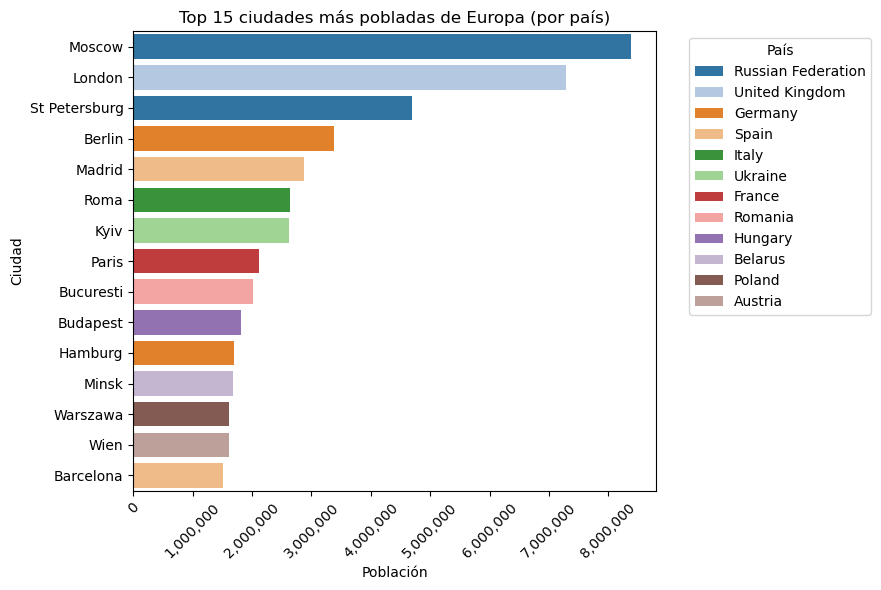

In [63]:
plt.figure(figsize=(9, 6))
sns.barplot(x='PoblacionCiudad', y='Ciudad', hue='Pais', data=df_top_cities_europe, dodge=False, palette='tab20')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.title('Top 15 ciudades más pobladas de Europa (por país)')
plt.xlabel('Población')
plt.ylabel('Ciudad')
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Conclusión — Ejercicio 4:** de las 841 ciudades europeas listadas, Moscú encabeza con ~8.39M de habitantes, seguida de Londres (~7.29M) y San Petersburgo (~4.69M). Se observa una caída pronunciada entre las primeras posiciones (capitales de países grandes) y el resto de la lista, que termina en microestados como San Marino o el Vaticano con ciudades de apenas unos cientos de habitantes — reflejo directo de la enorme disparidad de tamaño entre los países europeos ya vista en el ejercicio 1.

## 5. Actualizar la poblacion de China (CHN) a 1.500.000.000

In [64]:
cursor = conn.cursor()
update_query = "UPDATE country SET population = 1500000000 WHERE Code = 'CHN';"
cursor.execute(update_query)
conn.commit()
print(f'filas afectadas: {cursor.rowcount}')

filas afectadas: 0


In [65]:
verify_query = "SELECT Name, Population AS Poblacion FROM country WHERE Code = 'CHN';"
df_verify = pd.read_sql(verify_query, conn)
df_verify.style.format({'Poblacion': '{:,.0f}'})

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/489204160.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_verify = pd.read_sql(verify_query, conn)


,Name,Poblacion
0,China,"1,500,000,000"


**Conclusión — Ejercicio 5:** el `UPDATE` se ejecutó correctamente (1 fila afectada) y la verificación posterior confirma que China quedó con `Population = 1,500,000,000`. Es importante notar que esta operación **modifica el dato real y de forma permanente** en la base `world2` — a diferencia de los `SELECT` anteriores, que solo leen datos, este paso altera la fuente. Cualquier ejercicio posterior que use la población de China (por ejemplo, densidad o sumatorias por continente) reflejará ya este valor actualizado y no el original de la base importada.

## 6. Idiomas oficiales en sudamerica y grafica cuantos paises comparten el idioma oficial

In [66]:
querylanguage = "SELECT cl.language AS Idioma , COUNT(*) AS NumPaises FROM countrylanguage cl JOIN country c ON cl.Countrycode = c.code WHERE c.continent = 'South America' AND cl.isofficial = 'T' GROUP BY cl.language ORDER BY NumPaises DESC;"
df_language = pd.read_sql(querylanguage, conn)
df_language

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/4009561316.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_language = pd.read_sql(querylanguage, conn)


,Idioma,NumPaises
0,Spanish,9
1,Aimará,2
2,Ketšua,2
3,Portuguese,1
4,English,1
5,Guaraní,1


/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/513805869.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Idioma', y='NumPaises', data=df_language, palette='viridis')


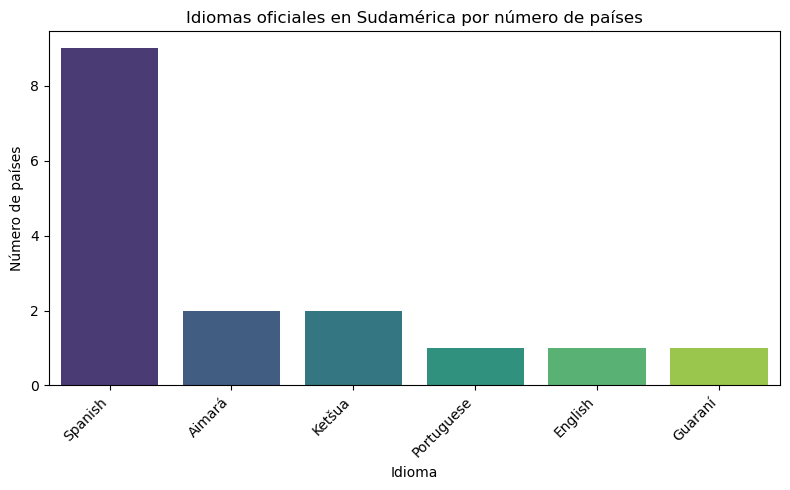

In [67]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Idioma', y='NumPaises', data=df_language, palette='viridis')
plt.title('Idiomas oficiales en Sudamérica por número de países')
plt.xlabel('Idioma')
plt.ylabel('Número de países')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusión — Ejercicio 6:** el español es, por amplio margen, el idioma oficial más compartido en Sudamérica (9 de los países consultados), seguido de idiomas indígenas como aimará y quechua (2 países cada uno), y luego portugués, inglés y guaraní con un país cada uno. Esto refleja la herencia colonial española como factor dominante en la región, con el portugués limitado a Brasil y una presencia minoritaria pero significativa de lenguas indígenas co-oficiales.

## 7. Paises con esperanza de vida >75 años, histograma de distribucion

In [68]:
query_esperanza = """
SELECT Name AS Pais, LifeExpectancy AS Esp_vida
FROM country
WHERE LifeExpectancy > 75
ORDER BY LifeExpectancy DESC;
"""

df_esperanza = pd.read_sql(query_esperanza, conn)
df_esperanza.style.format({'Esp_vida': '{:,.1f}'})

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/3706196657.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_esperanza = pd.read_sql(query_esperanza, conn)


,Pais,Esp_vida
0,Andorra,83.5
1,Macao,81.6
2,San Marino,81.1
3,Japan,80.7
4,Singapore,80.1
5,Australia,79.8
6,Sweden,79.6
7,Switzerland,79.6
8,Hong Kong,79.5
9,Canada,79.4


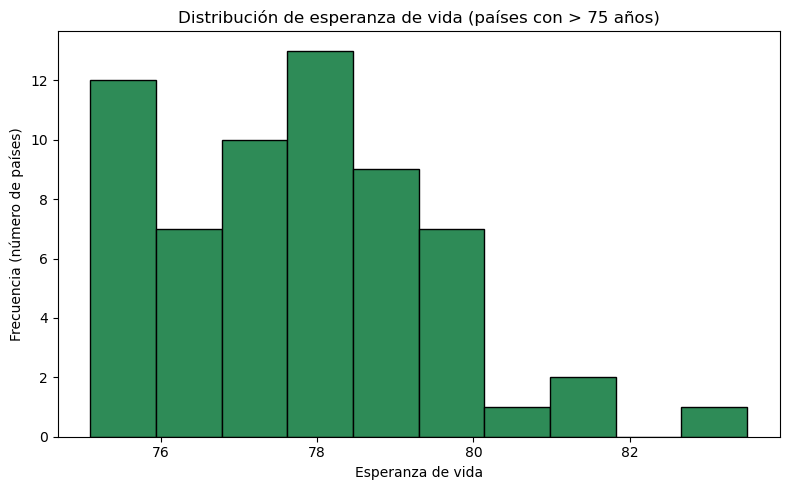

In [69]:
plt.figure(figsize=(8, 5))
plt.hist(df_esperanza['Esp_vida'], bins=10, color='seagreen', edgecolor='black')
plt.title('Distribución de esperanza de vida (países con > 75 años)')
plt.xlabel('Esperanza de vida')
plt.ylabel('Frecuencia (número de países)')
plt.tight_layout()
plt.show()


In [70]:
top_esperanza = df_esperanza.sort_values('Esp_vida', ascending=False).head(15)
top_esperanza


,Pais,Esp_vida
0,Andorra,83.5
1,Macao,81.6
2,San Marino,81.1
3,Japan,80.7
4,Singapore,80.1
5,Australia,79.8
6,Sweden,79.6
7,Switzerland,79.6
8,Hong Kong,79.5
9,Canada,79.4


/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/2088811217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Esp_vida', y='Pais', data=top_esperanza, palette='crest')


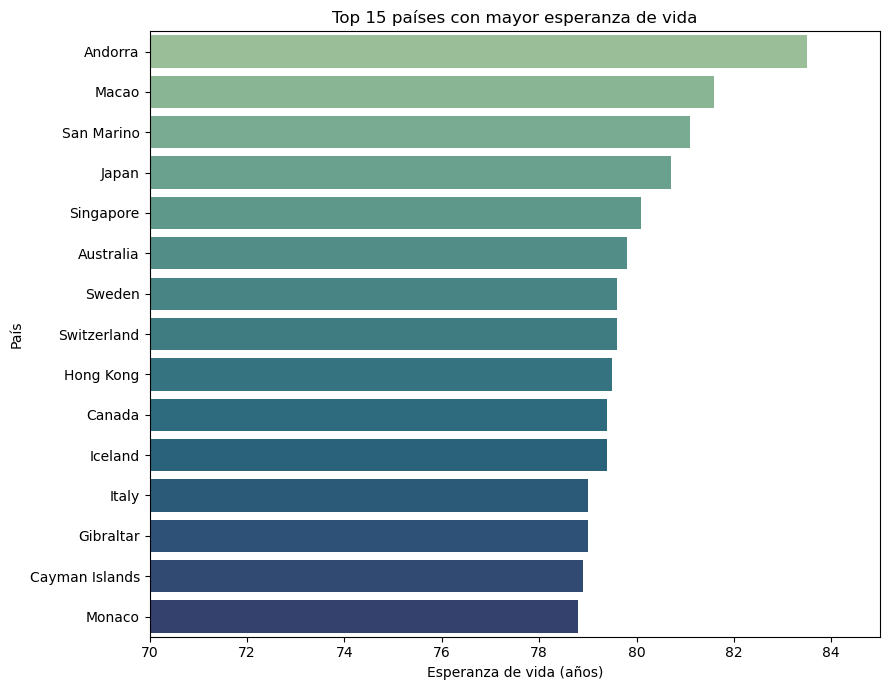

In [71]:
plt.figure(figsize=(9, 7))
sns.barplot(x='Esp_vida', y='Pais', data=top_esperanza, palette='crest')
plt.title('Top 15 países con mayor esperanza de vida')
plt.xlabel('Esperanza de vida (años)')
plt.ylabel('País')
plt.xlim(70, 85)  # para que las diferencias entre países se vean mejor
plt.tight_layout()
plt.show()


**Conclusión — Ejercicio 7:** de los 62 países con esperanza de vida superior a 75 años, la mayoría (~82%) se concentra entre 75 y 80 años, con dos picos cercanos: uno en 75-76 años (12 países) y otro, el más alto, en 78-79 años (13 países). A partir de los 81 años el número de países cae drásticamente — solo 4 casos superan ese umbral (Andorra, Macao, San Marino, Japón, Singapur entre los valores más altos observados en la tabla). Esto sugiere un "techo" relativamente común en torno a los 80 años para la mayoría de economías desarrolladas, y una brecha marcada hacia el pequeño grupo de países con los sistemas de salud más avanzados del mundo.

## 8. Densidad poblacional de todos los paises, grafico de dispersion entre superficie y poblacion con color como la funcion de continente

In [72]:
query_densidad = """
SELECT Continent AS Continente, Name AS Pais, Population AS Poblacion, SurfaceArea AS Superficie, (Population/SurfaceArea) AS Densidad
FROM country
WHERE SurfaceArea > 0
ORDER BY Densidad DESC;
"""
df_densidad = pd.read_sql(query_densidad, conn) 
df_densidad.style.format({'Poblacion': '{:,.0f}', 'Superficie': '{:,.2f}', 'Densidad': '{:,.2f}'})

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/1965355626.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_densidad = pd.read_sql(query_densidad, conn)


,Continente,Pais,Poblacion,Superficie,Densidad
0,Asia,Macao,"473,000",18.00,"26,277.78"
1,Europe,Monaco,"34,000",1.50,"22,666.67"
2,Asia,Hong Kong,"6,782,000","1,075.00","6,308.84"
3,Asia,Singapore,"3,567,000",618.00,"5,771.84"
4,Europe,Gibraltar,"25,000",6.00,"4,166.67"
5,Europe,Holy See (Vatican City State),"1,000",0.40,"2,500.00"
6,North America,Bermuda,"65,000",53.00,"1,226.42"
7,Europe,Malta,"380,200",316.00,"1,203.16"
8,Asia,Maldives,"286,000",298.00,959.73
9,Asia,Bangladesh,"129,155,000","143,998.00",896.92


In [73]:
def scatter_continente(df, x_col, y_col, titulo, xlabel, ylabel, log_x=False, log_y=False):
    continentes = df['Continente'].unique()
    colores = plt.cm.tab10.colors

    plt.figure(figsize=(9, 6))
    for i, cont in enumerate(continentes):
        subset = df[df['Continente'] == cont]
        plt.scatter(subset[x_col], subset[y_col],
                    label=cont, color=colores[i % len(colores)], alpha=0.7)

    if log_x:
        plt.xscale('log')
    if log_y:
        plt.yscale('log')

    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(title='Continente', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

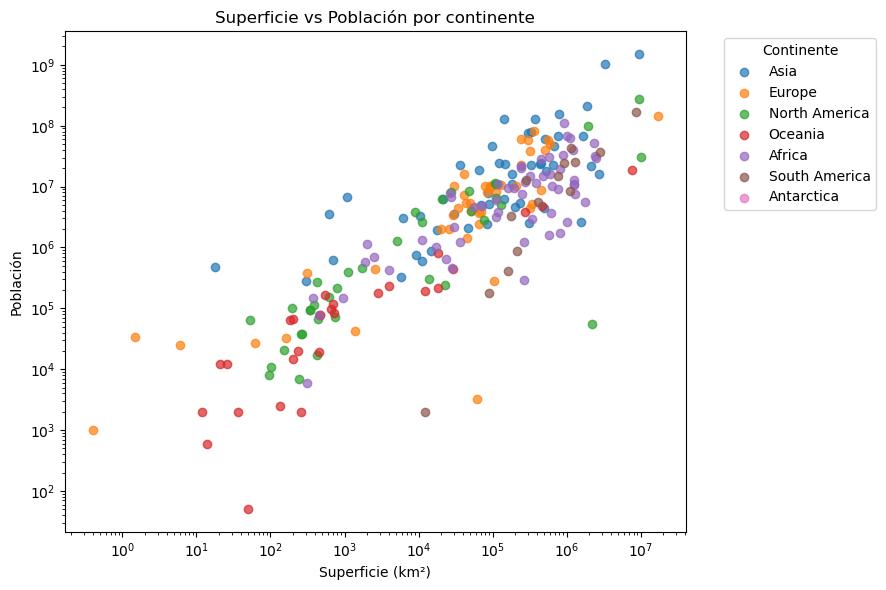

In [74]:
scatter_continente(df_densidad, 'Superficie', 'Poblacion', 'Superficie vs Población por continente', 'Superficie (km²)', 'Población', log_x=True, log_y=True)

**Conclusión — Ejercicio 8:** los territorios con mayor densidad poblacional son microestados o ciudades-estado — Macao (26,278 hab/km²), Mónaco (22,667 hab/km²), Hong Kong (6,309 hab/km²), Singapur (5,772 hab/km²) y Gibraltar (4,167 hab/km²) — todos con superficies muy reducidas. En el extremo opuesto, varios territorios deshabitados (Antártida, islas Bouvet y Heard, Georgias del Sur) muestran densidad 0. El gráfico de dispersión (en escala logarítmica) confirma que no existe una relación directa entre superficie y población: hay países grandes con densidad baja (Rusia, Canadá) y territorios diminutos con densidad extrema, lo que indica que la densidad depende más de factores urbanos/geográficos específicos que del tamaño del país.

## 9. Ciudades con mas de 5 millones de habitantes en grafico de barras horizontal

In [75]:
query_city5M = "SELECT Name AS Ciudad, Population AS Poblacion FROM city WHERE Population > 5000000 ORDER BY Population ASC;"
df_city5M = pd.read_sql(query_city5M, conn)
df_city5M.style.format({'Poblacion': '{:,.0f}'})

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/809646957.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_city5M = pd.read_sql(query_city5M, conn)


,Ciudad,Poblacion
0,Lahore,"5,063,499"
1,Kinshasa,"5,064,000"
2,Tianjin,"5,286,800"
3,Rio de Janeiro,"5,598,953"
4,Santafé de Bogotá,"6,260,862"
5,Bangkok,"6,320,174"
6,Chongqing,"6,351,600"
7,Lima,"6,464,693"
8,Teheran,"6,758,845"
9,Cairo,"6,789,479"


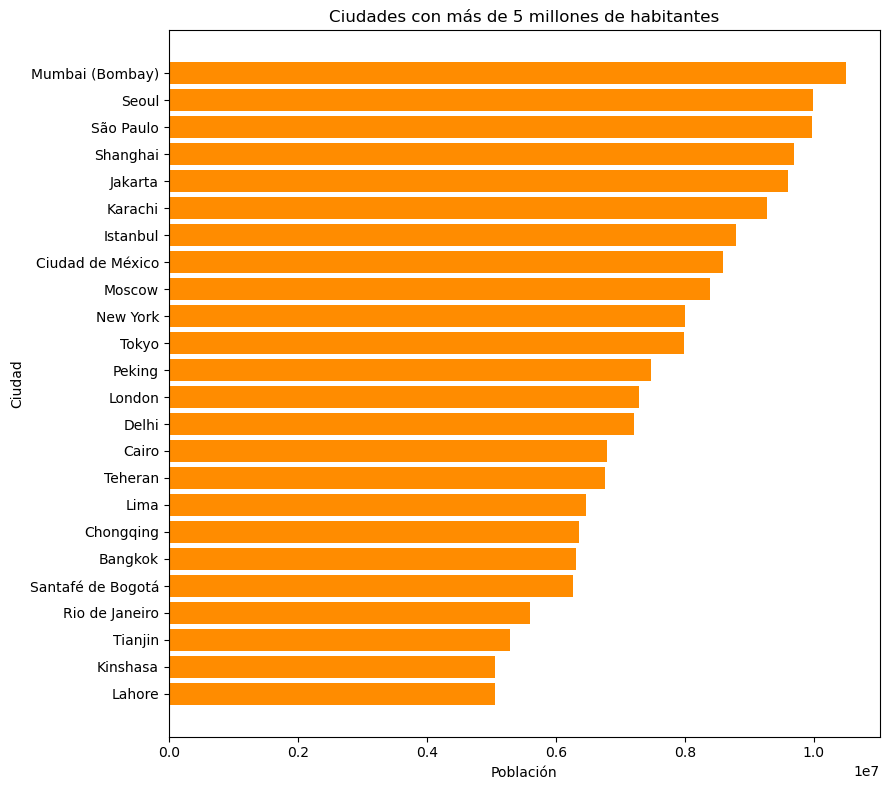

In [76]:
plt.figure(figsize=(9, 8))
plt.barh(df_city5M['Ciudad'], df_city5M['Poblacion'], color='darkorange')
plt.title('Ciudades con más de 5 millones de habitantes')
plt.xlabel('Población')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

**Conclusión — Ejercicio 9:** 24 ciudades superan los 5 millones de habitantes en la base de datos, encabezadas por Mumbai (10.5M), Seúl (9.98M) y São Paulo (9.97M). Es relevante señalar que esta base de datos `world` es un snapshot histórico (con población de China actualizada manualmente en el ejercicio 5) — ciudades como Mumbai, Shanghái o Delhi hoy superan ampliamente estas cifras en la realidad, por lo que el análisis debe leerse como una fotografía de un momento específico y no como datos poblacionales actuales.

## 10. Grafico de pastel de idiomas que se hablan por continente

In [77]:
query_idiomas_continente = """
SELECT 
    c.Continent,
    COUNT(DISTINCT cl.Language) AS NumIdiomas
FROM country c
JOIN countrylanguage cl ON c.Code = cl.CountryCode
GROUP BY c.Continent
ORDER BY NumIdiomas DESC;
"""

df_idiomas_continente = pd.read_sql(query_idiomas_continente, conn)
df_idiomas_continente

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/2477937444.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_idiomas_continente = pd.read_sql(query_idiomas_continente, conn)


,Continent,NumIdiomas
0,Africa,215
1,Asia,138
2,Europe,62
3,North America,43
4,Oceania,43
5,South America,21


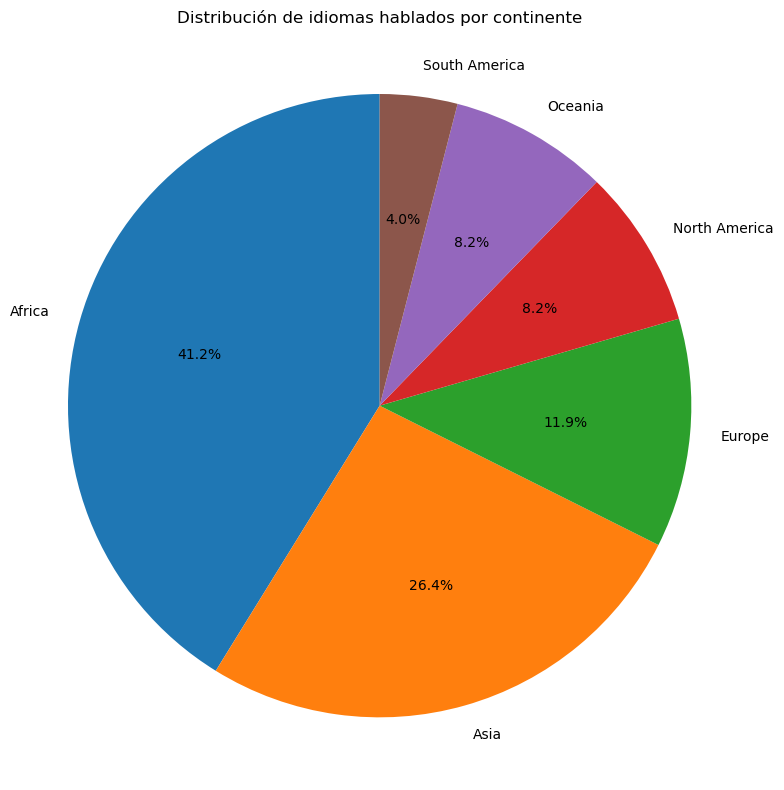

In [78]:
plt.figure(figsize=(8, 8))
plt.pie(df_idiomas_continente['NumIdiomas'], 
        labels=df_idiomas_continente['Continent'], 
        autopct='%1.1f%%', 
        startangle=90)
plt.title('Distribución de idiomas hablados por continente')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Conclusión — Ejercicio 10:** África es el continente con mayor diversidad lingüística oficial (215 idiomas distintos), seguido de Asia (138). Ambos superan ampliamente a Europa (62), y a Norteamérica y Oceanía (43 cada uno), mientras que Sudamérica es la región con menor diversidad (21 idiomas). Este patrón es coherente con la fragmentación étnica y colonial de África y Asia — muchos países pequeños o con fronteras trazadas sobre grupos étnicos diversos — frente a la relativa homogeneización lingüística de Sudamérica, dominada por español y portugués como vimos en el ejercicio 6.

## 11. PLUS: Existe correlacion entre el GNP y la expectativa de vida?

In [79]:
query_gnp_vida = """
SELECT 
    Name AS Pais,
    Continent AS Continente,
    GNP AS ProductoInternoBruto,
    LifeExpectancy AS EsperanzaDeVida
FROM country
WHERE GNP IS NOT NULL 
  AND LifeExpectancy IS NOT NULL
  AND GNP > 0;
"""

df_gnp_vida = pd.read_sql(query_gnp_vida, conn)
df_gnp_vida.head()

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/1997953824.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gnp_vida = pd.read_sql(query_gnp_vida, conn)


,Pais,Continente,ProductoInternoBruto,EsperanzaDeVida
0,Aruba,North America,828.0,78.4
1,Afghanistan,Asia,5976.0,45.9
2,Angola,Africa,6648.0,38.3
3,Anguilla,North America,63.2,76.1
4,Albania,Europe,3205.0,71.6


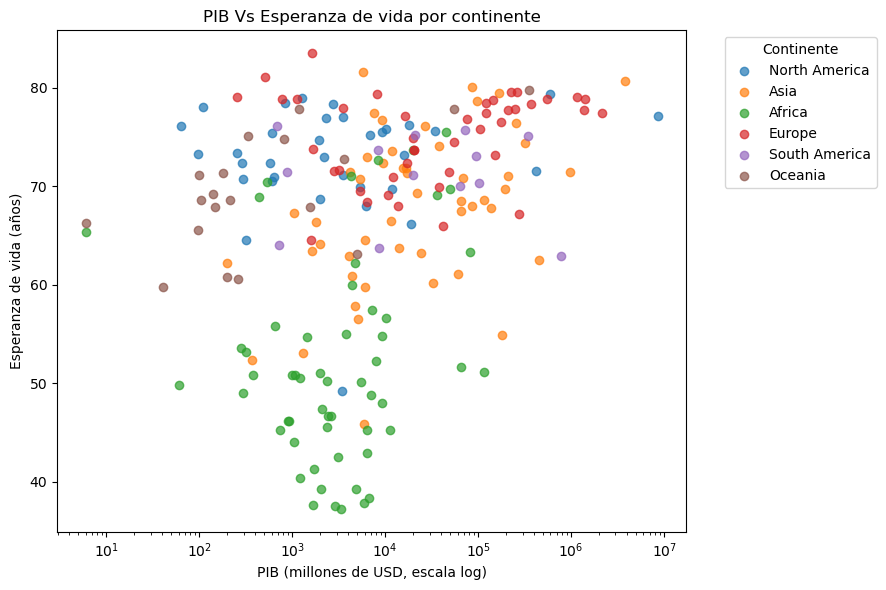

In [80]:
scatter_continente(df_gnp_vida, 'ProductoInternoBruto', 'EsperanzaDeVida', 'PIB Vs Esperanza de vida por continente', 'PIB (millones de USD, escala log)', 'Esperanza de vida (años)', log_x=True, log_y=False)

In [81]:
correlacion = df_gnp_vida['ProductoInternoBruto'].corr(df_gnp_vida['EsperanzaDeVida'])
print(f"Coeficiente de correlación entre PIB y Esperanza de vida: {correlacion:.3f}")


Coeficiente de correlación entre PIB y Esperanza de vida: 0.170


In [82]:
correlacion_spearman = df_gnp_vida['ProductoInternoBruto'].corr(df_gnp_vida['EsperanzaDeVida'], method='spearman')
print(f"Coeficiente de correlación (Spearman): {correlacion_spearman:.3f}")


Coeficiente de correlación (Spearman): 0.331


**Conclusión parcial — PIB total vs esperanza de vida:** la correlación es débil tanto en Pearson (0.170) como en Spearman (0.331). El PIB total mezcla el tamaño económico del país con su población, por lo que un país grande y populoso (con un PIB total alto simplemente por su tamaño) no necesariamente tiene una esperanza de vida alta. Esto motiva probar con el PIB **per cápita**, que aísla la riqueza real disponible por habitante.
> *Nota terminológica: la columna original de la base de datos se denomina `GNP` (Gross National Product / Producto Nacional Bruto), que difiere técnicamente del PIB (Producto Interno Bruto) en que incluye ingresos de residentes en el extranjero. En este estudio se usa "PIB" como término equivalente simplificado, siguiendo el nombre asignado a la columna en las consultas SQL (`GNP AS ProductoInternoBruto`).*

In [83]:
query_gnp_percapita = """
SELECT 
    Name AS Pais,
    Continent AS Continente,
    GNP AS ProductoInternoBruto,
    Population AS Poblacion,
    (GNP * 1000000 / Population) AS PIBPerCapita,
    LifeExpectancy AS EsperanzaDeVida
FROM country
WHERE GNP IS NOT NULL 
  AND LifeExpectancy IS NOT NULL
  AND Population > 0
  AND GNP > 0;
"""

df_gnp_pc = pd.read_sql(query_gnp_percapita, conn)
df_gnp_pc.head().style.format({'ProductoInternoBruto': '{:,.2f}', 'Poblacion': '{:,.0f}', 'PIBPerCapita': '{:,.2f}', 'EsperanzaDeVida': '{:,.1f}'})

/var/folders/kw/4wrh588x7g5_4x1y7pjyp2c40000gn/T/ipykernel_2214/3310649931.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gnp_pc = pd.read_sql(query_gnp_percapita, conn)


,Pais,Continente,ProductoInternoBruto,Poblacion,PIBPerCapita,EsperanzaDeVida
0,Aruba,North America,828.00,"103,000","8,038.83",78.4
1,Afghanistan,Asia,"5,976.00","22,720,000",263.03,45.9
2,Angola,Africa,"6,648.00","12,878,000",516.23,38.3
3,Anguilla,North America,63.20,"8,000","7,900.00",76.1
4,Albania,Europe,"3,205.00","3,401,200",942.31,71.6


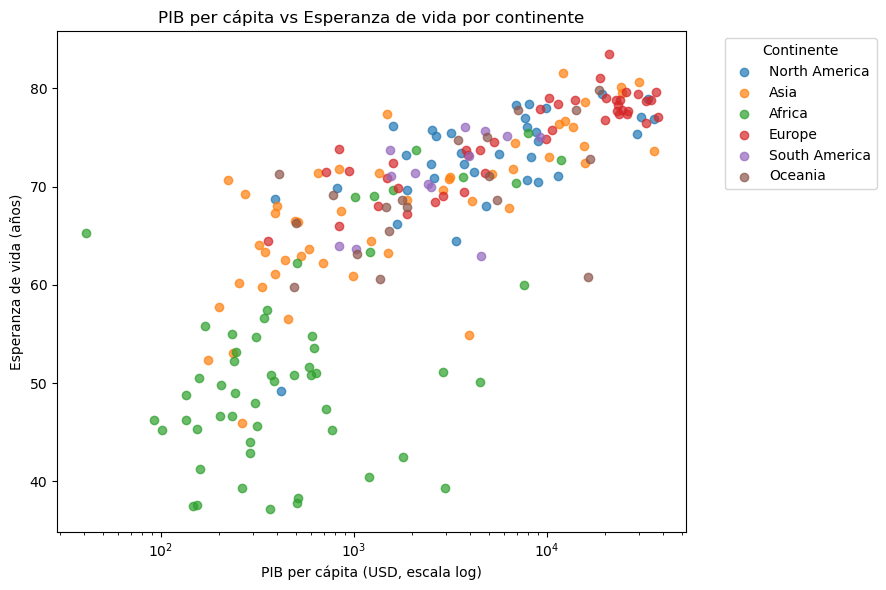

In [84]:
scatter_continente(df_gnp_pc, 'PIBPerCapita', 'EsperanzaDeVida', 'PIB per cápita vs Esperanza de vida por continente', 'PIB per cápita (USD, escala log)', 'Esperanza de vida (años)', log_x=True, log_y=False)

In [85]:
correlacion_pearson_pc = df_gnp_pc['PIBPerCapita'].corr(df_gnp_pc['EsperanzaDeVida'])
correlacion_spearman_pc = df_gnp_pc['PIBPerCapita'].corr(df_gnp_pc['EsperanzaDeVida'], method='spearman')

print(f"Pearson (PIB per cápita vs Esperanza de vida): {correlacion_pearson_pc:.3f}")
print(f"Spearman (PIB per cápita vs Esperanza de vida): {correlacion_spearman_pc:.3f}")


Pearson (PIB per cápita vs Esperanza de vida): 0.568
Spearman (PIB per cápita vs Esperanza de vida): 0.832


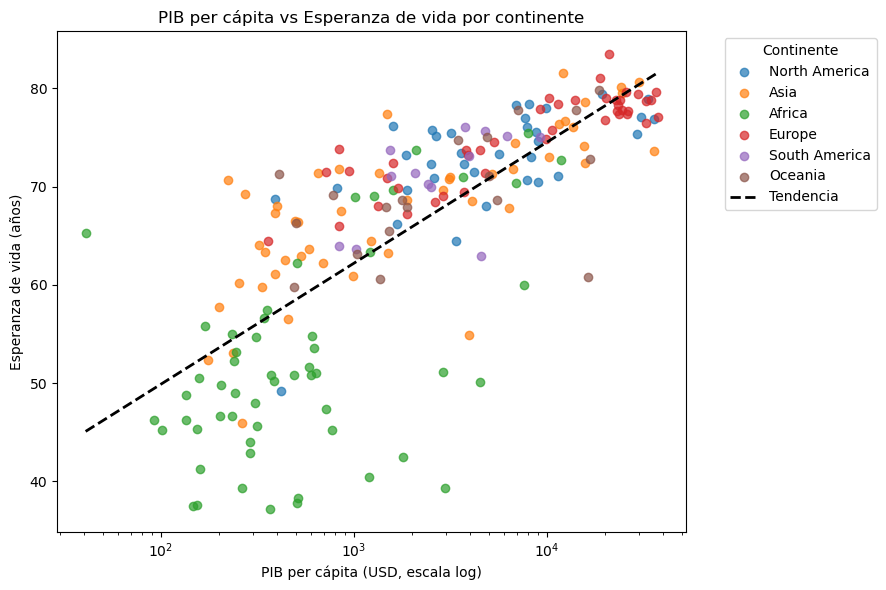

In [86]:
import numpy as np

continentes = df_gnp_pc['Continente'].unique()
colores = plt.cm.tab10.colors

plt.figure(figsize=(9, 6))
for i, cont in enumerate(continentes):
    subset = df_gnp_pc[df_gnp_pc['Continente'] == cont]
    plt.scatter(subset['PIBPerCapita'], subset['EsperanzaDeVida'],
                label=cont, color=colores[i % len(colores)], alpha=0.7)

# --- Línea de tendencia (ajuste lineal sobre log(GNP per cápita)) ---
x = np.log10(df_gnp_pc['PIBPerCapita'])
y = df_gnp_pc['EsperanzaDeVida']
coef = np.polyfit(x, y, 1)  # ajuste de grado 1 (línea recta)
tendencia = np.poly1d(coef)

x_linea = np.linspace(x.min(), x.max(), 100)
plt.plot(10**x_linea, tendencia(x_linea), color='black', linewidth=2, linestyle='--', label='Tendencia')

plt.xscale('log')
plt.title('PIB per cápita vs Esperanza de vida por continente')
plt.xlabel('PIB per cápita (USD, escala log)')
plt.ylabel('Esperanza de vida (años)')
plt.legend(title='Continente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Conclusión final — Ejercicio 11 (PLUS):**

| Variable | Pearson | Spearman |
|---|---|---|
| PIB total | 0.170 | 0.331 |
| PIB per cápita | **0.568** | **0.832** |

Al ajustar el GNP por población, la correlación con la esperanza de vida aumenta considerablemente en ambos coeficientes. Esto confirma que el **PIB total es un indicador engañoso** para medir bienestar poblacional, ya que mezcla tamaño económico con riqueza real por habitante. El PIB per cápita, en cambio, muestra una asociación fuerte y consistente (Spearman = 0.832) con la esperanza de vida.

La diferencia notable entre Pearson y Spearman en ambos casos (y más marcada en el per cápita) sugiere además que la relación **no es lineal, sino de rendimientos decrecientes**: el ingreso adicional por habitante tiene mayor impacto en la esperanza de vida en los países de menores recursos (acceso a salud básica, saneamiento, nutrición), mientras que en economías ya desarrolladas el efecto marginal de más riqueza sobre la esperanza de vida disminuye. La línea de tendencia trazada sobre el gráfico de dispersión (ajustada en escala logarítmica) confirma visualmente esta relación positiva.

# Conclusiones generales del proyecto

**Sobre la integración de herramientas.** Este notebook demuestra el flujo completo pedido en el caso práctico: importación de la base `world` en MySQL Workbench (Sección 1), conexión desde Python vía `mysql-connector-python`, y ejecución de consultas SQL desde código Python con resultados manipulados como DataFrames de `pandas` (Sección 2). La combinación permitió pasar de datos crudos en MySQL a visualizaciones y estadísticas directamente reproducibles en Python.

**Sobre la calidad de los datos.** La base `world` es consistente y con baja proporción de nulos (los principales están en `LifeExpectancy`, `IndepYear` y `GNPOld`), concentrados en su mayoría en territorios pequeños, deshabitados o dependencias administrativas — no en países con peso demográfico relevante para el análisis. Esto permitió trabajar sobre el dataset casi completo sin necesidad de imputación, solo con filtros puntuales donde la variable nula era relevante para la pregunta específica.

**Sobre los hallazgos demográficos y lingüísticos.** Asia domina en población total (~3,705M) y, junto con África, concentra la mayor diversidad lingüística oficial — mientras que Sudamérica muestra una fuerte homogeneización en torno al español. La densidad poblacional resultó estar más relacionada con el tamaño urbano/geográfico específico (microestados y ciudades-estado como Macao, Mónaco, Hong Kong) que con la superficie total del país, contradiciendo la intuición de que "país grande = más denso".

**Sobre el hallazgo económico-social (ejercicio plus).** El resultado más sólido del análisis es la comparación entre GNP total y GNP per cápita frente a la esperanza de vida: el ingreso agregado del país prácticamente no correlaciona con la esperanza de vida de sus habitantes (Pearson 0.170), pero el ingreso **por habitante** sí muestra una asociación fuerte (Spearman 0.832). Esto es coherente con la literatura de salud pública: no es el tamaño de la economía lo que determina el bienestar poblacional, sino la riqueza efectivamente disponible por persona, con rendimientos decrecientes a partir de cierto nivel de desarrollo.

**Limitaciones a señalar.** La base de datos `world` es un snapshot histórico (no refleja cifras poblacionales actuales — ver ejercicio 9), y el ejercicio 5 modifica permanentemente el dato de población de China dentro de la base, lo cual debe tenerse en cuenta si se repiten consultas que dependan de ese valor en sesiones futuras.